In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from src.preprocessing import process_store_data
from src.features import attach_store_data, make_features, make_targets
# NOTE: train_df['Open'] == 0 -> train_df['Sales'] = 0. This happens always
# TODO: Clusters on sales and/or holidays that occur together?


DATA_DIR = '../datasets/rossmann-store-sales'
STORE_FILE = os.path.join(DATA_DIR, 'store.csv')
TRAIN_FILE = os.path.join(DATA_DIR, 'train.csv')
TEST_FILE = os.path.join(DATA_DIR, 'test.csv')

FORECAST_HORIZON = 6*7 # We're forecasting daily for 6 weeks into the future
LAGS = [1, 2, 7, 30, 90, 182, 365]
DIFFS = [1, 30, 90, 182, 365]
ROLL_WINDOWS = { 7: 1, # window: lags
                30: [30, 90, 182, 365]}
HOLIDAY_WINDOWS = [-7, 0, 7]


In [2]:
df_train = pd.read_csv(TRAIN_FILE,
                       parse_dates=['Date'],
                       dtype={'StateHoliday': str} # 0 -> '0'
                       ).drop(['Customers'], axis=1)

# NOTE: train_df['Open'] == 0 -> train_df['Sales'] = 0.
# This happens always. 
# We'll model without this and apply the rule at the end.
df_train.loc[df_train['Open'] == 0, 'Sales'] = np.nan
df_train['Sales'] = (df_train
                     .groupby(["Store"], group_keys=False)
                     .apply(lambda g: g
                            .set_index("Date")["Sales"]
                            .interpolate(method="time"),
                            include_groups=False)
                     .reset_index(level=0, drop=True))
df_train.drop(['Open'], axis=1, inplace=True)

In [3]:
store_df = pd.read_csv(STORE_FILE)
store_df = process_store_data(store_df)
df_train_store = attach_store_data(df_train, store_df)

# TODO: Predict log-transformed sales?
df_features = make_features(df_train_store, lags=LAGS, roll_windows=ROLL_WINDOWS, diffs=DIFFS, holiday_windows=HOLIDAY_WINDOWS)
#targets = make_targets(df=df_train[['Date', 'Store', 'Sales']], horizon=FORECAST_HORIZON)

#test_df = pd.read_csv(TEST_FILE, index_col=0, parse_dates=['Date'])
#test_df = features.attach_store_data(test_df, store_df)

In [4]:
sales_df = df_train[['Date', 'Store', 'Sales']].copy()

In [28]:
df_p = (pd.pivot(sales_df, index=sales_df.columns[0], columns=sales_df.columns[1], values=sales_df.columns[2])
            .sort_index())  # Sorted from oldest to newest

df_p.head()

Store,1,2,3,4,5,6,7,8,9,10,...,1106,1107,1108,1109,1110,1111,1112,1113,1114,1115
Date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,20668.0,18727.0,18843.0,21643.0,23557.0,22885.0,22213.0,18592.0,16391.0,17264.0,...,5007.0,4649.0,5243.0,6905.000000,5838.000000,4771.0,4540.0,4297.0,3697.0,3697.0
2013-01-02,7094.0,7350.0,6757.0,6709.5,6662.0,7140.0,10954.0,9113.0,8937.0,10203.0,...,25737.0,24286.0,22835.0,19875.000000,18809.000000,16670.0,17559.0,19263.0,19495.0,19727.0
2013-01-03,19560.0,14013.0,8466.0,10882.0,10628.5,10375.0,8967.0,6886.0,7624.5,8363.0,...,10999.0,12174.0,11423.0,10742.000000,11694.000000,12268.0,9871.0,7474.0,7903.0,7852.0
2013-01-04,2854.0,4415.0,4639.0,3523.0,4647.0,4509.0,4027.0,3545.0,5381.0,5547.0,...,7473.0,7665.0,8969.0,8600.333333,8231.666667,7863.0,10564.0,12869.0,12881.0,13517.0
2013-01-05,5424.5,5724.0,3909.0,3939.0,3788.5,3638.0,5620.0,5495.0,5131.0,5888.0,...,7224.0,8096.0,5917.0,3738.000000,6745.000000,6096.0,5719.0,6679.0,8288.0,5571.0


In [49]:
roll = df_p.rolling(window=365//4)

ii = 0
for rolled in roll:
    ii += 1
    if ii == 365//4:
        break

In [50]:
rolled

Store,1,2,3,4,5,6,7,8,9,10,...,1106,1107,1108,1109,1110,1111,1112,1113,1114,1115
Date,,,,,,,,,,,,,,,,,,,,,
2013-01-01,20668.0,18727.0,18843.0,21643.0,23557.0,22885.000000,22213.000000,18592.0,16391.0,17264.0,...,5007.000000,4649.000000,5243.0,6905.000000,5838.000000,4771.0,4540.0,4297.0,3697.0,3697.0
2013-01-02,7094.0,7350.0,6757.0,6709.5,6662.0,7140.000000,10954.000000,9113.0,8937.0,10203.0,...,25737.000000,24286.000000,22835.0,19875.000000,18809.000000,16670.0,17559.0,19263.0,19495.0,19727.0
2013-01-03,19560.0,14013.0,8466.0,10882.0,10628.5,10375.000000,8967.000000,6886.0,7624.5,8363.0,...,10999.000000,12174.000000,11423.0,10742.000000,11694.000000,12268.0,9871.0,7474.0,7903.0,7852.0
2013-01-04,2854.0,4415.0,4639.0,3523.0,4647.0,4509.000000,4027.000000,3545.0,5381.0,5547.0,...,7473.000000,7665.000000,8969.0,8600.333333,8231.666667,7863.0,10564.0,12869.0,12881.0,13517.0
2013-01-05,5424.5,5724.0,3909.0,3939.0,3788.5,3638.000000,5620.000000,5495.0,5131.0,5888.0,...,7224.000000,8096.000000,5917.0,3738.000000,6745.000000,6096.0,5719.0,6679.0,8288.0,5571.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-03-28,2634.0,3832.0,4042.0,3819.0,4479.0,4385.333333,4291.666667,4198.0,5003.5,5809.0,...,7112.666667,7174.333333,7236.0,7273.000000,7362.000000,7525.0,7604.0,9853.0,8785.0,7717.0
2013-03-29,4610.0,4121.0,3840.0,3968.0,4205.0,4197.000000,4211.500000,4226.0,4381.0,5097.0,...,3518.000000,3930.000000,3499.0,3068.000000,4403.000000,4424.0,4811.0,4817.0,6083.0,4358.5
2013-03-30,6980.0,6905.0,7190.0,9275.0,8533.0,7791.000000,5712.000000,5114.0,4859.0,4834.0,...,4376.000000,4718.000000,4513.0,4308.000000,4794.000000,6501.0,5945.0,6552.0,8404.0,6507.0


In [51]:
# Extract components
rolled["year"] = rolled.index.year
rolled["quarter"] = rolled.index.quarter
rolled["month"] = rolled.index.month
rolled["week"] = rolled.index.isocalendar().week     # ISO week number

# Extract components
rolled["day_of_week"]   = rolled.index.dayofweek      # Monday=0, Sunday=6
rolled["day_of_month"]  = rolled.index.day
rolled["day_of_year"]   = rolled.index.dayofyear

# For day of quarter, compute relative to quarter start
quarter_start_day = rolled.index.to_period("Q").start_time
rolled["day_of_quarter"] = (rolled.index - quarter_start_day).days + 1


<Axes: xlabel='Date'>

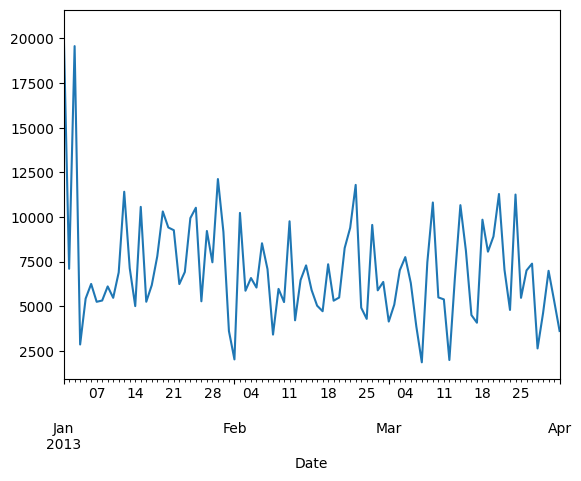

In [52]:
rolled[1].plot()

Index(['Date', 'Store', 'Sales', 'year', 'quarter', 'month', 'week',
       'day_of_week', 'day_of_month', 'day_of_year', 'day_of_quarter'],
      dtype='object')